# NB05a — Data Stack Builder (Files + Patches) v14

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


## v14 changes vs v13 (only this section is new)

Adds NB03e v47 R2b/P1d outputs to the data_stack pipeline. **No existing entries removed or modified.**

- **Cell 12 (ALIGN-DERIVED-TEMPORAL):** added 6 new entries to `build_derived_temporal_groups` for the new R2b/P1d output directories:
  - `temporal_{coh,card,ms}_rolling_accum` -> `temporal/{COH,CARD,MS}/rolling_accum/`
  - `temporal_{coh,card,ms}_block_accum`   -> `temporal/{COH,CARD,MS}/block_accum/`
- **Cell 12 (JSON meta copy block):** added 6 new entries for `rolling_accumulators_r2b_meta.json` and `block_accumulators_p1d_meta.json` per modality.
- **Cell 24 (CATALOG):** added 6 new entries to `source_scan` for the new subdirs, plus extended product_type detection to recognize `rolling_accum` and `block_accum`.

All other cells unchanged (PRIMARY, DERIVED-PER-SCENE, PLAN-COPY, BBOX-VERIFY, TEMPORAL-AUDIT, VALIDATE, PATCH-CATALOG, PATCHES, MASKS, xBD-COPY, STACK-SYNC, SQLITE-CHECK).

## v10 design (preserved)

>
> This program is free software: you can redistribute it and/or modify
> the Free Software Foundation, either version 3 of the License, or
> (at your option) any later version.
>
> This program is distributed in the hope that it will be useful,
> but WITHOUT ANY WARRANTY; without even the implied warranty of
> MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
>
> along with this program. If not, see <https://www.gnu.org/licenses/>.

| Field | Value |
|---|---|
| Notebook | `05a_bda_Data_Stack_Builder_v10.ipynb` |
| Version | `v10` |
| Pipeline position | Dataset construction. After NB04a (QC/QA). Before NB05a2 (audit) and NB05b (parquets). |
| License | Code: AGPL-3.0-or-later — see [LICENSE](../LICENSE) |
| Last validated | 2026-04-14 |

## Narrative

**This notebook is the bridge between data processing and machine learning.** It creates
the portable, self-contained `data_stack` directory that can be copied to DGX/cluster
and used by NB06-NB11 without any NB02/NB03 dependencies, zips, or GDrive mounts.

### Why a Data Stack?

The BDA pipeline has two fundamentally different phases:
1. **Data Pipeline** (NB01-NB04): Acquisition, processing, QA — produces TIFs spread
   across multiple directories (SAR_CARD_DIR, SAR_COH_DIR, MS_DIR, TEMPORAL_ROOT, etc.)
2. **ML Pipeline** (NB06-NB11): Feature extraction, analysis, experiments — needs a
   single organized directory with consistent filenames and aligned grids.

NB05a is the **translation layer** between these phases. It copies TIFs from scattered
source directories into one `data_stack/{city}/` directory per city, renames them to
the double-underscore convention, verifies pixel alignment against AOI.geojson bbox,
populates the `bda.sqlite` catalog, and generates 64x64 patches for DL experiments.

**Key principle:** NB05a creates FILES (TIFs, patches, sqlite). NB05b creates PARQUETS
(feature tables for ML). This separation allows rerunning feature extraction without
re-copying hundreds of GB of TIFs.

### Pipeline: CLEANUP -> ALIGN -> VERIFY -> AUDIT -> VALIDATE -> CATALOG -> PATCHES -> SYNC

---

## Cell CLEANUP: Delete Old-Named TIFs

Removes TIF subdirectories in `data_stack/{city}/` that were written with old
naming conventions (City_product.tif). Keeps: `reference_grid.json`,
`building_labels.tif`, `damage_mask.tif`, GeoJSONs, patch catalogs.
Run once before fresh ALIGN with `FORCE_RERUN=True`.

---

## Cell STACK-ALIGN-PRIMARY: Align Source Products to Data Stack

Copies source TIFs (CARD, COH, MS, landuse) from SATELLITE_DIR into
`STACK_ROOT/{city}/` using `stack_align.py`. For each product group:
1. Scans source directory for TIFs
2. Renames via `stack_align_rename.py` (15+ filename patterns normalized)
3. Copies to destination with skip-if-exists logic
4. Verifies raster dimensions match city reference grid

**Product groups aligned:**

| Group | Source | Destination |
|-------|--------|-------------|
| SAR CARD flat | `SAR_CARD_DIR/{city}/` | `data_stack/{city}/SAR_CARD/` |
| SAR COH flat | `SAR_COH_DIR/{city}/` | `data_stack/{city}/SAR_SLC/` |
| MS flat | `MS_DIR/{city}/` | `data_stack/{city}/multispectral/` |
| Landuse per-date | `LANDUSE_DIR/{city}/` | `data_stack/{city}/landuse/` |

---

## Cell PLAN-COPY: Copy Scene Plan into Data Stack

Copies `nb02a_scene_plan.json` into `STACK_ROOT/` for portability. When the data stack
is copied to DGX/cluster, the plan travels with it — no need to access OUTPUTS_DIR.

---

## Cell STACK-ALIGN-DERIVED: Align NB03e Derived Products

Same alignment logic as PRIMARY but for derived products from NB03e:

| Group | Source | Destination |
|-------|--------|-------------|
| MS composites | `MS_DIR/{city}/composites/` | `multispectral/composites/` |
| MS RGB | `MS_DIR/{city}/rgb/` | `multispectral/rgb/` |
| MS NBR | `MS_DIR/{city}/nbr/` | `multispectral/nbr/` |
| CARD temporal stats | `SAR_CARD_DIR/{city}/temporal_stats/` | `SAR_CARD/temporal_stats/` |
| COH baseline stats | `SAR_COH_DIR/{city}/coherence_baseline/` | `SAR_SLC/coherence_baseline/` |
| COH post baseline | `TEMPORAL_ROOT/{city}/COH/post_baseline/` | `temporal/COH/post_baseline/` |
| COH z-scores | `TEMPORAL_ROOT/{city}/COH/zscore/` | `temporal/COH/zscore/` |
| COH rolling | `TEMPORAL_ROOT/{city}/COH/rolling/` | `temporal/COH/rolling/` |
| CARD rolling | `TEMPORAL_ROOT/{city}/CARD/rolling/` | `temporal/CARD/rolling/` |
| CARD rolling stats | `TEMPORAL_ROOT/{city}/CARD/rolling_stats/` | `temporal/CARD/rolling_stats/` |
| CARD block stats | `TEMPORAL_ROOT/{city}/CARD/block_stats/` | `temporal/CARD/block_stats/` |

---

## Cell ALIGN-LANDUSE: Flatten Landuse Period Dirs

Normalizes landuse filenames and flattens period subdirectories into `landuse/flat/`.
Renames: `landuse_classification` -> `lulc__class`, `ndvi` -> `s2__ndvi`, etc.
Appends `__YYYYMMDD` from period subdir name. Idempotent (skips existing).

---

## Cell BBOX-VERIFY: Check Raster Dimensions vs AOI BBOX

Verifies every TIF in `data_stack/{city}/` has dimensions matching the city's
AOI.geojson `aoi_bbox`. Catches: wrong resolution (not 10m), wrong CRS,
clipping to wrong geometry, off-by-one pixel errors from resampling.

This is the critical alignment gate — if any TIF fails, NB05b zonal stats will
produce misaligned features.

---

## Cell TEMPORAL-AUDIT: Quarantine Late Post-Battle Scenes

Scans data_stack for MS and SAR scenes whose dates fall far outside the expected
temporal window. Late post-battle scenes (e.g., 2025 scenes for a city whose
battle ended in 2022) dilute temporal statistics. These are quarantined, not deleted.

---

## Cell VALIDATE: Data Stack Completeness Audit

Runs `stack_validate.py` over the entire data_stack. Produces a manifest listing
every TIF per city with status (present/missing/extra). Checks that expected product
groups exist for each city based on tier and battle dates.

---

## Cell CATALOG: Populate bda.sqlite from Data Stack

Creates/updates the `bda.sqlite` database at `STACK_ROOT/bda.sqlite` — the single
catalog that travels with the data stack. Registers:
- Cities table (from cities_config + AOI.geojson metadata)
- Products table (every TIF in data_stack with modality, date, path)
- Rename LUT (old filename -> new filename mapping for traceability)
- Processing runs (timestamps, parameters)

**bda.sqlite at STACK_ROOT** is the real database. The orphan at `data/satellite/bda.sqlite`
(1.6 MB) should not be used — DBeaver must point to `data_stack/bda.sqlite` (36+ MB).

---

## Cell PATCH-CATALOG: Generate Patch Grid

Generates a 64x64 pixel patch grid per city from AOI.geojson aoi_bbox. Records which
patches overlap with buildings (from building_labels.tif) and their damage status.
Patch catalog stored as JSON per city in data_stack.

| Parameter | Value |
|-----------|-------|
| PATCH_SIZE | 64 pixels (640m at 10m resolution) |
| MIN_VALID_PCT | Minimum fraction of non-nodata pixels in patch |
| ONLY_LABELED | If True, only generate patches containing buildings |

---

## Cell PATCHES: Generate 64x64 Pre/Post Patches

Extracts actual pixel patches from MS composites (RGB: B04, B03, B02) for DL experiments.
Pre-patch = last scene before battle_start. Post-patch = first scene after battle_stop.

Output: `DATASET_ROOT/bda_patches/patches_ms_64/` with matching pre/post pairs + masks.
These patches are consumed by NB09d U-Net experiments.

---

## Cell STACK-SYNC: Mirror Data Stack to GDrive

Mirrors `data_stack` from local SSD to GDrive backup. The local copy is always the
processing copy (fast I/O); GDrive is backup only. One-directional sync (local -> GDrive).

---

## Cell EXPLORE: bda.sqlite Health Check

Diagnostic cell that queries bda.sqlite for: table row counts, duplicate detection,
orphan products (in DB but not on disk), missing products (on disk but not in DB).

---

## NB05 Series Architecture

| Notebook | What | Creates |
|----------|------|---------|
| **NB05a** | Data Stack Builder | TIFs in `data_stack/`, patches, `bda.sqlite` |
| **NB05a2** | Data Stack Audit + Prune | Validates data_stack integrity (mostly redundant if NB01-NB04 clean) |
| **NB05b** | Parquet Builder | `bda_period_aggregated.parquet`, `bda_temporal_*.parquet` |

The split ensures: re-extracting features (NB05b) does not re-copy TIFs (NB05a).
Copy = hours (hundreds of GB). Feature extraction = minutes (zonal stats on aligned TIFs).

## Inputs

| Data | Source | Format |
|------|--------|--------|
| All source TIFs (CARD, COH, MS) | NB03a/b/c via NB03d/f | GeoTIFF |
| All derived TIFs (stats, rolling, composites, landuse) | NB03e via NB03f | GeoTIFF |
| `building_labels.tif` + `damage_mask.tif` | NB03e RASTERIZE | GeoTIFF |
| `AOI.geojson` per city | NB01b | GeoJSON (aoi_bbox, buildings) |
| `nb02a_scene_plan.json` | NB02a | JSON (copied into stack) |
| `cities_config.json` | Manual | JSON |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Aligned TIFs per city | `STACK_ROOT/{city}/` | NB05b (feature extraction) |
| `bda.sqlite` catalog | `STACK_ROOT/bda.sqlite` | NB05b, NB06-NB11 |
| 64x64 MS patches (pre/post) | `DATASET_ROOT/bda_patches/` | NB09d (DL) |
| Patch catalogs (JSON) | `STACK_ROOT/{city}/` | NB09d |
| `nb02a_scene_plan.json` copy | `STACK_ROOT/` | Portability |
| GDrive mirror | `GDrive/data/data_stack/` | Backup |

## Python Modules

| Module | What |
|--------|------|
| `stack_align.py` | Copy + align TIFs, verify_bbox |
| `stack_align_rename.py` | 15+ filename normalization patterns |
| `stack_temporal_audit.py` | Quarantine late post-battle scenes |
| `stack_validate.py` | Completeness audit + manifest |
| `stack_catalog.py` | BDACatalog class, bda.sqlite population |
| `stack_patches.py` | Patch grid generation + extraction |
| `stack_rasterize.py` | Building footprint + damage rasterization |

## Cell Structure

| Cell | ID | What | Lines | Status |
|------|----|------|-------|--------|
| 0-1 | — | Documentation + pipeline overview | — | — |
| 2 | Cell 3 | Config (TIER, FORCE_RERUN, PATCH_SIZE) | 14 | Config |
| 3 | Cell 4 | Load global_setup | 11 | Config |
| 4-5 | CLEANUP | Delete old-named TIFs (run once) | — | Optional |
| 6 | ALIGN-PRIMARY | Copy + rename source TIFs to data_stack | 37 | **Core** |
| 7 | PLAN-COPY | Copy scene plan into data_stack | 28 | **Core** |
| 8-9 | ALIGN-DERIVED | Copy + rename derived TIFs to data_stack | 32 | **Core** |
| 10-11 | ALIGN-LANDUSE | Flatten landuse period dirs | 67 | **Core** |
| 12-13 | BBOX-VERIFY | Check raster dims vs AOI bbox | 4 | **Core** |
| 14-15 | TEMPORAL-AUDIT | Quarantine late post-battle scenes | 15 | **Core** |
| 16-17 | VALIDATE | Data stack completeness audit | 11 | **Core** |
| 18-19 | CATALOG | Populate bda.sqlite | 142 | **Core** |
| 20-21 | PATCH-CATALOG | Generate patch grid + AOI coverage | 13 | **Core** |
| 22-23 | PATCHES | Generate 64x64 pre/post patches | 42 | **Core** |
| 24-25 | STACK-SYNC | Mirror to GDrive | — | Maintenance |
| 26-27 | EXPLORE | bda.sqlite health check | 129 | Diagnostic |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.4 Dataset Construction — Data Stack Architecture | ALIGN-PRIMARY, ALIGN-DERIVED | Copy + rename strategy, portability |
| 3.4 Dataset Construction — Alignment Verification | BBOX-VERIFY | Pixel grid consistency |
| 3.4 Dataset Construction — Temporal Filtering | TEMPORAL-AUDIT | Late scene quarantine |
| 3.4 Dataset Construction — Data Catalog | CATALOG | bda.sqlite schema, rename LUT |
| 3.4 Dataset Construction — Patch Generation | PATCHES | 64x64 patches for DL |
| 3.4 Dataset Construction — Portability | PLAN-COPY, STACK-SYNC | Self-contained stack concept |

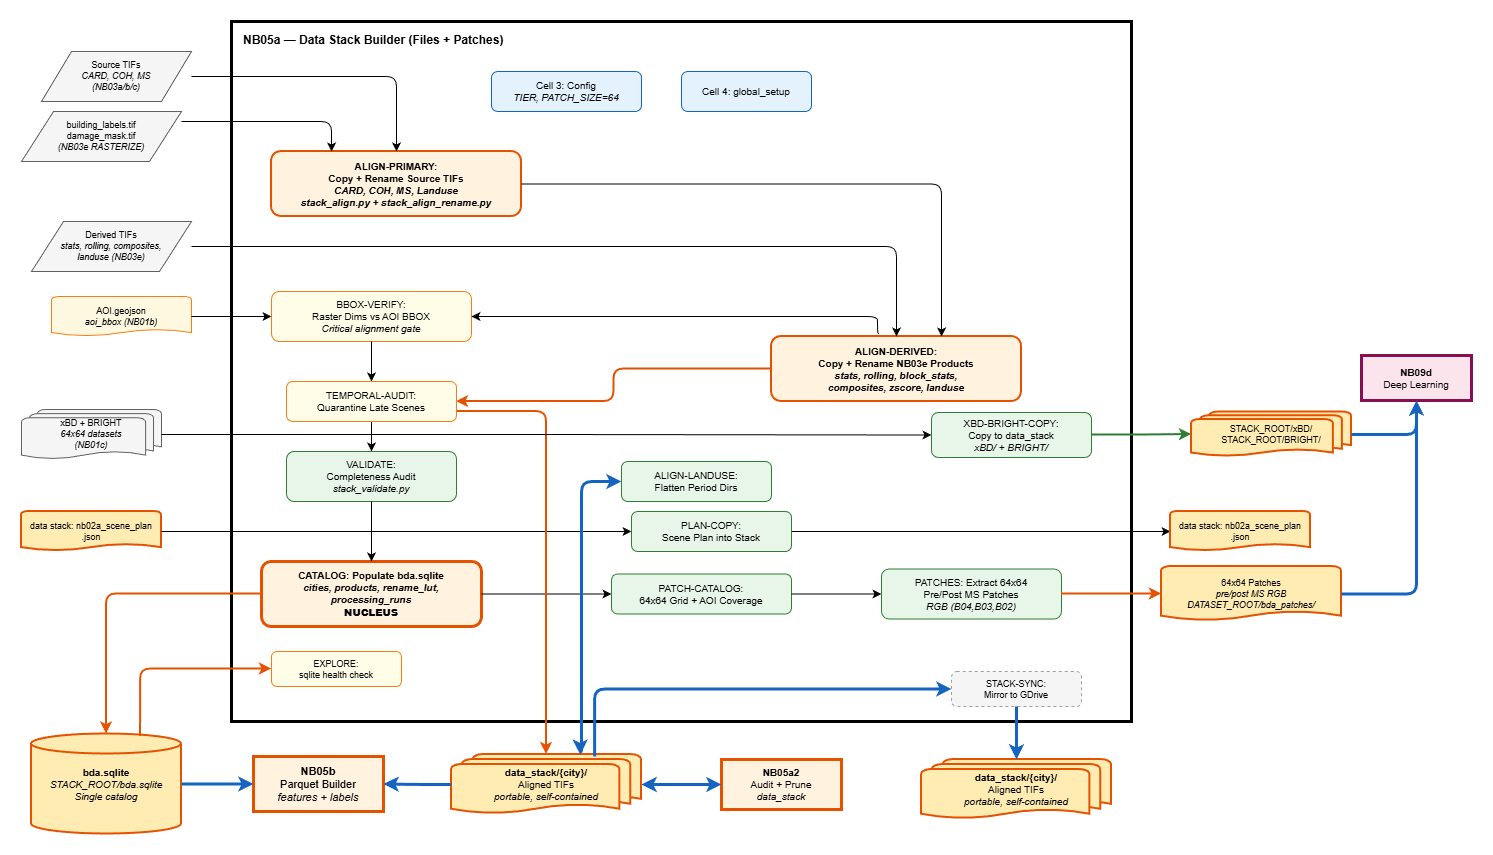

## Pipeline: CLEANUP -> ALIGN -> VERIFY -> AUDIT -> VALIDATE -> CATALOG -> PATCHES -> MASKS -> SYNC

In [1]:
# @title CELL 3: NB05a CONFIG
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
CLIP_BY_POLYGON = False
FORCE_RERUN = False
CLEANUP_DATASTACK = False
# ---- ALIGN ----
FORCE_RERUN_ALIGN = False
FORCE_RERUN_DERIVED = True
# ---- PATCHES ----
PATCH_SIZE = 64
ONLY_LABELED = True
# ---- SYNC ----
FORCE_OVERWRITE = True
DELETE_FIRST = False

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-04-26 09:32:24
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.2/7452.0 GB (6541.8 GB free)
  GDrive (F:)     1374.0/3726.0 GB (2352.0 GB free)
  Local data      11560.0/14901.9 GB (3341.8 GB free)
  Data stack      1374.0/3726.0 GB (2352.0 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL CLEANUP: DELETE OLD-NAMED TIFs BEFORE RENAME (run once)

# @title CELL CLEANUP: DELETE OLD-NAMED TIFs BEFORE RENAME (run once)
# Removes TIF subdirs that ALIGN wrote with old City_product.tif names.
# Keeps: reference_grid.json, building_labels.tif, damage_mask.tif, GeoJSONs, patch catalogs.
# After this, run ALIGN-PRIMARY + ALIGN-DERIVED with FORCE_RERUN=True.
import shutil
if CLEANUP_DATASTACK:
    ALIGN_SUBDIRS = [
        'SAR_CARD', 'SAR_SLC', 'multispectral',
        'landuse', 'temporal',
        'Dietrich_baseline', 'Dietrich_assessment',
    ]
    print("=" * 70)
    print("CLEANUP: DELETE OLD-NAMED TIFs IN DATA_STACK")
    print("=" * 70)
    print(f"  STACK_ROOT: {STACK_ROOT}")
    print(f"  Cities: {len(CITIES_TO_PROCESS)}")
    n_deleted = 0
    for city_name in CITIES_TO_PROCESS:
        city_dir = STACK_ROOT / city_name
        if not city_dir.exists():
            continue
        city_deleted = 0
        for subdir_name in ALIGN_SUBDIRS:
            subdir = city_dir / subdir_name
            if subdir.exists():
                shutil.rmtree(str(subdir))
                city_deleted += 1
        if city_deleted:
            print(f"  {city_name}: deleted {city_deleted} subdirectories")
            n_deleted += city_deleted
    print(f"\n  Total: {n_deleted} subdirectories deleted across {len(CITIES_TO_PROCESS)} cities")
    print(f"  Kept: reference_grid.json, building_labels.tif, damage_mask.tif, *.geojson, patch_catalog_*.json")
    print("=" * 70)
else:
    print("CLEANUP: skipped (CLEANUP_DATASTACK=False)")

In [3]:
# diagnostic: find what cell 4 actually loads and whether the constant is there
import platform, os

if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'

print(f"cell 4 loads from: {_setup}")
print(f"file exists:       {os.path.exists(_setup)}")

with open(_setup) as f:
    txt = f.read()
print(f"file size bytes:   {len(txt)}")
print(f"file has MS_RGB_SUBDIR:          {'MS_RGB_SUBDIR' in txt}")
print(f"file has MS_NBR_SUBDIR:          {'MS_NBR_SUBDIR' in txt}")
print(f"file has COH_DROP_ACCUMULATOR:   {'COH_DROP_ACCUMULATOR_SUBDIR' in txt}")

# show mtime so we can see whether overwrite actually landed here
import datetime
mtime = datetime.datetime.fromtimestamp(os.path.getmtime(_setup))
print(f"file mtime:        {mtime}")

print()
print("in notebook globals (after cell 4 supposedly ran):")
for k in ['MS_RGB_SUBDIR', 'MS_NBR_SUBDIR', 'MS_RGB_PREPOST_SUBDIR',
         'SAR_CARD_PREPOST_SUBDIR', 'COH_DROP_ACCUMULATOR_SUBDIR']:
    print(f"  {k:40s} {k in globals()}  value={globals().get(k, '<MISSING>')}")

cell 4 loads from: /content/drive_f/masterthesis/notebooks/global_setup.py
file exists:       True
file size bytes:   40053
file has MS_RGB_SUBDIR:          True
file has MS_NBR_SUBDIR:          True
file has COH_DROP_ACCUMULATOR:   True
file mtime:        2026-04-20 23:58:38.372047

in notebook globals (after cell 4 supposedly ran):
  MS_RGB_SUBDIR                            True  value=rgb
  MS_NBR_SUBDIR                            True  value=nbr
  MS_RGB_PREPOST_SUBDIR                    True  value=rgb_prepost
  SAR_CARD_PREPOST_SUBDIR                  True  value=card_prepost
  COH_DROP_ACCUMULATOR_SUBDIR              True  value=coh_drop_accumulator


# CELL STACK: ALIGN NB03 PRIMARY PRODUCTS TO DATA_STACK

In [4]:
# @title CELL STACK-ALIGN-PRIMARY: ALIGN NB03 SAR/MS/COH TO DATA_STACK
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
import stack_align
importlib.reload(stack_align)
from stack_align import run_align
import stack_align_rename
importlib.reload(stack_align_rename)
from stack_align_rename import rename_tif_for_convention

def build_primary_groups(city_name):
    if CLIP_BY_POLYGON:
        sar_card = SAR_CARD_POLYGON_DIR / city_name
        sar_slc = SAR_COH_CITY_POLYGON / city_name
    else:
        sar_card = SAR_CARD_DIR / city_name
        sar_slc = SAR_COH_DIR / city_name
    return {
        "SAR_CARD":      {"src_dir": sar_card, "dst_subdir": "SAR_CARD/flat", "recursive": False, "rename_fn": rename_tif_for_convention},
        "SAR_COH":       {"src_dir": sar_slc, "dst_subdir": "SAR_SLC/flat", "recursive": False, "rename_fn": rename_tif_for_convention},
        "multispectral": {"src_dir": MS_DIR / city_name, "dst_subdir": "multispectral/flat", "recursive": False, "rename_fn": rename_tif_for_convention},
    }

PRIMARY_SUMMARY = run_align(
    cities=CITIES_TO_PROCESS,
    stack_root=STACK_ROOT,
    cities_dir=CITIES_DIR,
    align_groups_fn=build_primary_groups,
    create_grid=True,
    force_rerun=FORCE_RERUN_ALIGN,
    unosat_cities_dir=UNOSAT_CITIES_DIR,
    logs_dir=LOGS_DIR,
    label="PRIMARY",
)

STACK PRIMARY: ALIGN TO UTM REFERENCE GRID
  Stack root:    /mnt/f/PROJECTS/masterthesis/data_stack
  Cities:        21
  Create grid:   True
  Force rerun:   False

  [1/21] Avdiivka
    Grid: 1024x1024 EPSG:32637 (26.8% polygon fill)
    SAR_CARD                 :  130 skip (all up to date)
    SAR_COH                  :  126 skip (all up to date)
    multispectral            :  420 skip (all up to date)
    Vectors: 5 copied
    VALID: 2890 rasters all 1024x1024

  [2/21] Borodyanka
    Grid: 3072x2816 EPSG:32635 (59.3% polygon fill)
    SAR_CARD                 :   20 skip (all up to date)
    SAR_COH                  :   18 skip (all up to date)
    Vectors: 5 copied
    VALID: 243 rasters all 3072x2816

  [3/21] Bucha
    Grid: 768x768 EPSG:32636 (44.7% polygon fill)
    SAR_CARD                 :   18 skip (all up to date)
    SAR_COH                  :   16 skip (all up to date)
    multispectral            :  195 skip (all up to date)
    Vectors: 5 copied
    VALID: 837 raste

# CELL STACK: ALIGN NB03 DERIVED PRODUCTS TO DATA_STACK

In [5]:
# @title CELL STACK-ALIGN-DERIVED-PER-SCENE: ALIGN NB03E PER-SCENE PRODUCTS TO DATA_STACK
# Per-scene derived products (rgb, nbr, landuse, prepost). Cheap to regenerate
# in NB03e. If something is wrong here, rerun this cell after regenerating the
# per-scene products in NB03e; it's fast. Aggregated temporal products live in
# the next cell (STACK-ALIGN-DERIVED-TEMPORAL).
from stack_align import run_align
from stack_align_rename import rename_tif_for_convention

def build_derived_perscene_groups(city_name):
    return {
        "ms_rgb":         {"src_dir": MS_DIR / city_name / MS_RGB_SUBDIR,                  "dst_subdir": f"multispectral/{MS_RGB_SUBDIR}",           "recursive": False, "rename_fn": rename_tif_for_convention},
        "ms_nbr":         {"src_dir": MS_DIR / city_name / MS_NBR_SUBDIR,                  "dst_subdir": f"multispectral/{MS_NBR_SUBDIR}",           "recursive": False, "rename_fn": rename_tif_for_convention},
        "ms_rgb_prepost": {"src_dir": MS_DIR / city_name / MS_RGB_PREPOST_SUBDIR,          "dst_subdir": f"multispectral/{MS_RGB_PREPOST_SUBDIR}",   "recursive": False, "rename_fn": rename_tif_for_convention},
        "card_prepost":   {"src_dir": SAR_CARD_DIR / city_name / SAR_CARD_PREPOST_SUBDIR,  "dst_subdir": f"SAR_CARD/{SAR_CARD_PREPOST_SUBDIR}",      "recursive": False, "rename_fn": rename_tif_for_convention},
        "landuse":        {"src_dir": LANDUSE_DIR / city_name,                             "dst_subdir": "landuse",                                   "recursive": True,  "rename_fn": rename_tif_for_convention},
    }

DERIVED_PERSCENE_SUMMARY = run_align(
    cities=CITIES_TO_PROCESS,
    stack_root=STACK_ROOT,
    cities_dir=CITIES_DIR,
    align_groups_fn=build_derived_perscene_groups,
    create_grid=False,
    force_rerun=FORCE_RERUN_DERIVED,
    copy_vectors=False,
    logs_dir=LOGS_DIR,
    label="DERIVED_PERSCENE",
)

# ---- copy JSON meta files for prepost products (run_align only copies TIFs) ----
import shutil
_json_copies = 0
for city_name in CITIES_TO_PROCESS:
    for src_sub, dst_sub in [
        (MS_DIR / city_name / MS_RGB_PREPOST_SUBDIR / "rgb_prepost_meta.json",
         STACK_ROOT / city_name / "multispectral" / MS_RGB_PREPOST_SUBDIR / "rgb_prepost_meta.json"),
        (SAR_CARD_DIR / city_name / SAR_CARD_PREPOST_SUBDIR / "card_prepost_meta.json",
         STACK_ROOT / city_name / "SAR_CARD" / SAR_CARD_PREPOST_SUBDIR / "card_prepost_meta.json"),
    ]:
        if src_sub.exists():
            dst_sub.parent.mkdir(parents=True, exist_ok=True)
            if not dst_sub.exists() or FORCE_RERUN_DERIVED:
                shutil.copy2(src_sub, dst_sub)
                _json_copies += 1
print(f"  Per-scene prepost JSON meta files copied: {_json_copies}")


STACK DERIVED_PERSCENE: ALIGN TO UTM REFERENCE GRID
  Stack root:    /mnt/f/PROJECTS/masterthesis/data_stack
  Cities:        21
  Create grid:   False
  Force rerun:   True

  [1/21] Avdiivka
    ms_rgb                   :   28 ok,    0 skip,    0 err  (of 28)
    ms_nbr                   :   28 ok,    0 skip,    0 err  (of 28)
    ms_rgb_prepost           :    7 ok,    0 skip,    0 err  (of 7)
    card_prepost             :    6 ok,    0 skip,    0 err  (of 6)
    landuse                  :  308 ok,    0 skip,    0 err  (of 308)
    VALID: 2890 rasters all 1024x1024

  [2/21] Borodyanka
    card_prepost             :    6 ok,    0 skip,    0 err  (of 6)
    VALID: 243 rasters all 3072x2816

  [3/21] Bucha
    ms_rgb                   :   13 ok,    0 skip,    0 err  (of 13)
    ms_nbr                   :   13 ok,    0 skip,    0 err  (of 13)
    ms_rgb_prepost           :    5 ok,    0 skip,    0 err  (of 5)
    card_prepost             :    6 ok,    0 skip,    0 err  (of 6)
    landu

In [6]:
# @title CELL STACK-ALIGN-DERIVED-TEMPORAL: ALIGN NB03E TEMPORAL/AGGREGATED PRODUCTS TO DATA_STACK
# Cross-scene aggregated products (slow to regenerate in NB03e): composites,
# rolling, rolling_stats, block_stats, post_baseline, zscore, accumulators,
# Dietrich baseline/assessment. If primary and per-scene derived cells are fine,
# NB03e can regenerate these in parallel while downstream notebooks consume
# the primary/per-scene side of the data_stack.
from stack_align import run_align
from stack_align_rename import rename_tif_for_convention

def build_derived_temporal_groups(city_name):
    return {
        "ms_composites":               {"src_dir": MS_DIR / city_name / MS_COMPOSITES_SUBDIR,                         "dst_subdir": f"multispectral/{MS_COMPOSITES_SUBDIR}",              "recursive": True,  "rename_fn": rename_tif_for_convention},
        "card_temporal_stats":         {"src_dir": SAR_CARD_DIR / city_name / SAR_CARD_TEMPORAL_STATS_SUBDIR,         "dst_subdir": f"SAR_CARD/{SAR_CARD_TEMPORAL_STATS_SUBDIR}",         "recursive": False, "rename_fn": rename_tif_for_convention},
        "coherence_baseline":          {"src_dir": SAR_COH_DIR / city_name / SAR_COH_BASELINE_SUBDIR,                 "dst_subdir": f"SAR_SLC/{SAR_COH_BASELINE_SUBDIR}",                 "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_coh_post_bl":        {"src_dir": TEMPORAL_ROOT / city_name / "COH" / COH_POST_BASELINE_SUBDIR,      "dst_subdir": f"temporal/COH/{COH_POST_BASELINE_SUBDIR}",           "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_coh_zscore":         {"src_dir": TEMPORAL_ROOT / city_name / "COH" / COH_ZSCORE_SUBDIR,             "dst_subdir": f"temporal/COH/{COH_ZSCORE_SUBDIR}",                  "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_coh_rolling":        {"src_dir": TEMPORAL_ROOT / city_name / "COH" / ROLLING_SUBDIR,                "dst_subdir": f"temporal/COH/{ROLLING_SUBDIR}",                     "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_coh_rolling_stats":  {"src_dir": TEMPORAL_ROOT / city_name / "COH" / ROLLING_STATS_SUBDIR,          "dst_subdir": f"temporal/COH/{ROLLING_STATS_SUBDIR}",               "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_coh_drop":           {"src_dir": TEMPORAL_ROOT / city_name / "COH" / COH_DROP_ACCUMULATOR_SUBDIR,   "dst_subdir": f"temporal/COH/{COH_DROP_ACCUMULATOR_SUBDIR}",        "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_card_rolling":       {"src_dir": TEMPORAL_ROOT / city_name / "CARD" / ROLLING_SUBDIR,               "dst_subdir": f"temporal/CARD/{ROLLING_SUBDIR}",                    "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_card_rolling_stats": {"src_dir": TEMPORAL_ROOT / city_name / "CARD" / ROLLING_STATS_SUBDIR,         "dst_subdir": f"temporal/CARD/{ROLLING_STATS_SUBDIR}",              "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_card_block_stats":   {"src_dir": TEMPORAL_ROOT / city_name / "CARD" / CARD_BLOCK_STATS_SUBDIR,      "dst_subdir": f"temporal/CARD/{CARD_BLOCK_STATS_SUBDIR}",           "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_card_drop":          {"src_dir": TEMPORAL_ROOT / city_name / "CARD" / CARD_DROP_ACCUMULATOR_SUBDIR, "dst_subdir": f"temporal/CARD/{CARD_DROP_ACCUMULATOR_SUBDIR}",      "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_ms_change":          {"src_dir": TEMPORAL_ROOT / city_name / "MS" / MS_CHANGE_ACCUMULATOR_SUBDIR,   "dst_subdir": f"temporal/MS/{MS_CHANGE_ACCUMULATOR_SUBDIR}",        "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_ms_maha":            {"src_dir": TEMPORAL_ROOT / city_name / "MS" / MS_MAHA_ACCUMULATOR_SUBDIR,     "dst_subdir": f"temporal/MS/{MS_MAHA_ACCUMULATOR_SUBDIR}",          "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_lu_change":          {"src_dir": TEMPORAL_ROOT / city_name / "LANDUSE" / LU_CHANGE_ACCUMULATOR_SUBDIR, "dst_subdir": f"temporal/LANDUSE/{LU_CHANGE_ACCUMULATOR_SUBDIR}", "recursive": False, "rename_fn": rename_tif_for_convention},
        # --- v47 additions: NB03e R2b (rolling_accum) + P1d (block_accum) ---
        "temporal_coh_rolling_accum":  {"src_dir": TEMPORAL_ROOT / city_name / "COH"  / "rolling_accum", "dst_subdir": "temporal/COH/rolling_accum",   "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_card_rolling_accum": {"src_dir": TEMPORAL_ROOT / city_name / "CARD" / "rolling_accum", "dst_subdir": "temporal/CARD/rolling_accum",  "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_ms_rolling_accum":   {"src_dir": TEMPORAL_ROOT / city_name / "MS"   / "rolling_accum", "dst_subdir": "temporal/MS/rolling_accum",    "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_coh_block_accum":    {"src_dir": TEMPORAL_ROOT / city_name / "COH"  / "block_accum",   "dst_subdir": "temporal/COH/block_accum",     "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_card_block_accum":   {"src_dir": TEMPORAL_ROOT / city_name / "CARD" / "block_accum",   "dst_subdir": "temporal/CARD/block_accum",    "recursive": False, "rename_fn": rename_tif_for_convention},
        "temporal_ms_block_accum":     {"src_dir": TEMPORAL_ROOT / city_name / "MS"   / "block_accum",   "dst_subdir": "temporal/MS/block_accum",      "recursive": False, "rename_fn": rename_tif_for_convention},
        "Dietrich_baseline":           {"src_dir": DIETRICH_DRIVE / city_name / "baseline",                           "dst_subdir": "Dietrich_baseline",                                  "recursive": False, "rename_fn": rename_tif_for_convention},
        "Dietrich_assessment":         {"src_dir": DIETRICH_DRIVE / city_name / "assessment",                         "dst_subdir": "Dietrich_assessment",                                "recursive": False, "rename_fn": rename_tif_for_convention},
    }

DERIVED_TEMPORAL_SUMMARY = run_align(
    cities=CITIES_TO_PROCESS,
    stack_root=STACK_ROOT,
    cities_dir=CITIES_DIR,
    align_groups_fn=build_derived_temporal_groups,
    create_grid=False,
    force_rerun=FORCE_RERUN_DERIVED,
    copy_vectors=False,
    logs_dir=LOGS_DIR,
    label="DERIVED_TEMPORAL",
)

# ---- copy JSON meta files for temporal/aggregated products (run_align only copies TIFs) ----
import shutil
_json_copies = 0
for city_name in CITIES_TO_PROCESS:
    for src_sub, dst_sub in [
        (TEMPORAL_ROOT / city_name / "CARD" / CARD_BLOCK_STATS_SUBDIR / "block_stats_meta.json",
         STACK_ROOT / city_name / "temporal" / "CARD" / CARD_BLOCK_STATS_SUBDIR / "block_stats_meta.json"),
        (TEMPORAL_ROOT / city_name / "COH" / COH_DROP_ACCUMULATOR_SUBDIR / "coh_drop_accumulator_meta.json",
         STACK_ROOT / city_name / "temporal" / "COH" / COH_DROP_ACCUMULATOR_SUBDIR / "coh_drop_accumulator_meta.json"),
        (TEMPORAL_ROOT / city_name / "CARD" / CARD_DROP_ACCUMULATOR_SUBDIR / "card_drop_accumulator_meta.json",
         STACK_ROOT / city_name / "temporal" / "CARD" / CARD_DROP_ACCUMULATOR_SUBDIR / "card_drop_accumulator_meta.json"),
        (TEMPORAL_ROOT / city_name / "MS" / MS_CHANGE_ACCUMULATOR_SUBDIR / "ms_change_accumulator_meta.json",
         STACK_ROOT / city_name / "temporal" / "MS" / MS_CHANGE_ACCUMULATOR_SUBDIR / "ms_change_accumulator_meta.json"),
        (TEMPORAL_ROOT / city_name / "MS" / MS_MAHA_ACCUMULATOR_SUBDIR / "ms_mahalanobis_accumulator_meta.json",
         STACK_ROOT / city_name / "temporal" / "MS" / MS_MAHA_ACCUMULATOR_SUBDIR / "ms_mahalanobis_accumulator_meta.json"),
        (TEMPORAL_ROOT / city_name / "LANDUSE" / LU_CHANGE_ACCUMULATOR_SUBDIR / "landuse_change_accumulator_meta.json",
         STACK_ROOT / city_name / "temporal" / "LANDUSE" / LU_CHANGE_ACCUMULATOR_SUBDIR / "landuse_change_accumulator_meta.json"),
        # --- v47 additions: R2b rolling_accum meta ---
        (TEMPORAL_ROOT / city_name / "COH"  / "rolling_accum" / "rolling_accumulators_r2b_meta.json",
         STACK_ROOT    / city_name / "temporal" / "COH"  / "rolling_accum" / "rolling_accumulators_r2b_meta.json"),
        (TEMPORAL_ROOT / city_name / "CARD" / "rolling_accum" / "rolling_accumulators_r2b_meta.json",
         STACK_ROOT    / city_name / "temporal" / "CARD" / "rolling_accum" / "rolling_accumulators_r2b_meta.json"),
        (TEMPORAL_ROOT / city_name / "MS"   / "rolling_accum" / "rolling_accumulators_r2b_meta.json",
         STACK_ROOT    / city_name / "temporal" / "MS"   / "rolling_accum" / "rolling_accumulators_r2b_meta.json"),
        # --- v47 additions: P1d block_accum meta ---
        (TEMPORAL_ROOT / city_name / "COH"  / "block_accum" / "block_accumulators_p1d_meta.json",
         STACK_ROOT    / city_name / "temporal" / "COH"  / "block_accum" / "block_accumulators_p1d_meta.json"),
        (TEMPORAL_ROOT / city_name / "CARD" / "block_accum" / "block_accumulators_p1d_meta.json",
         STACK_ROOT    / city_name / "temporal" / "CARD" / "block_accum" / "block_accumulators_p1d_meta.json"),
        (TEMPORAL_ROOT / city_name / "MS"   / "block_accum" / "block_accumulators_p1d_meta.json",
         STACK_ROOT    / city_name / "temporal" / "MS"   / "block_accum" / "block_accumulators_p1d_meta.json"),
    ]:
        if src_sub.exists():
            dst_sub.parent.mkdir(parents=True, exist_ok=True)
            if not dst_sub.exists() or FORCE_RERUN_DERIVED:
                shutil.copy2(src_sub, dst_sub)
                _json_copies += 1
print(f"  Temporal/aggregated JSON meta files copied: {_json_copies}")


STACK DERIVED_TEMPORAL: ALIGN TO UTM REFERENCE GRID
  Stack root:    /mnt/f/PROJECTS/masterthesis/data_stack
  Cities:        21
  Create grid:   False
  Force rerun:   True

  [1/21] Avdiivka
    ms_composites            :   66 ok,    0 skip,    0 err  (of 66)
    card_temporal_stats      :   32 ok,    0 skip,    0 err  (of 32)
    coherence_baseline       :    6 ok,    0 skip,    0 err  (of 6)
    temporal_coh_post_bl     :    6 ok,    0 skip,    0 err  (of 6)
    temporal_coh_zscore      :   63 ok,    0 skip,    0 err  (of 63)
    temporal_coh_rolling     :  169 ok,    0 skip,    0 err  (of 169)
    temporal_coh_drop        :    9 ok,    0 skip,    0 err  (of 9)
    temporal_card_rolling    :  350 ok,    0 skip,    0 err  (of 350)
    temporal_card_rolling_stats:   16 ok,    0 skip,    0 err  (of 16)
    temporal_card_block_stats:  160 ok,    0 skip,    0 err  (of 160)
    temporal_card_drop       :    9 ok,    0 skip,    0 err  (of 9)
    temporal_ms_change       :    9 ok,    0 sk

In [7]:
# @title CELL PLAN-COPY: COPY SCENE PLAN INTO DATA_STACK (portability)
import shutil
from pathlib import Path

print("=" * 70)
print("PLAN-COPY: COPY SCENE PLAN INTO DATA_STACK")
print("=" * 70)

plan_src = OUTPUTS_DIR / 'nb02a_scene_plan.json'
plan_dst = STACK_ROOT / 'nb02a_scene_plan.json'

if plan_src.exists():
    shutil.copy2(plan_src, plan_dst)
    size_kb = plan_dst.stat().st_size // 1024
    print(f"  Copied: {plan_src}")
    print(f"      ->  {plan_dst} ({size_kb} KB)")
else:
    print(f"  WARNING: plan not found at {plan_src}")
    print(f"  Run NB02a first to create the plan.")

# also copy cities_config.json for portability
cfg_src = CITIES_CONFIG_FILE
cfg_dst = STACK_ROOT / 'cities_config.json'
if cfg_src.exists():
    shutil.copy2(cfg_src, cfg_dst)
    print(f"  Copied: {cfg_src.name} -> {cfg_dst}")
print("=" * 70)


PLAN-COPY: COPY SCENE PLAN INTO DATA_STACK
  Copied: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
      ->  /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json (2084 KB)
  Copied: cities_config.json -> /mnt/f/PROJECTS/masterthesis/data_stack/cities_config.json


# CELL STACK-NB03d: ALIGN NB03e PRODUCTS INTO DATA_STACK

# CELL ALIGN-LANDUSE: FLATTEN LANDUSE PERIOD DIRS TO landuse/flat/
# Normalizes filenames (landuse_classification -> lulc__class, ndvi -> s2__ndvi, etc)
# Appends __YYYYMMDD from period subdir name. Idempotent (skips existing).

In [8]:
# @title CELL ALIGN-LANDUSE: FLATTEN PERIOD DIRS TO landuse/flat/
import shutil, re
from stack_align_rename import normalize_landuse_stem

WRONG_STEMS = [
    'landuse_classification',
    'ndvi', 'nbr', 'bsi', 'savi', 'mndwi', 'ndbi',
]

total_copied = 0
total_skipped = 0
total_cleaned = 0

for city_name in CITIES_TO_PROCESS:
    city_stack = STACK_ROOT / city_name
    lu_root = city_stack / 'landuse'
    flat_dir = lu_root / 'flat'
    flat_dir.mkdir(parents=True, exist_ok=True)

    # --- CLEANUP: delete wrongly-named files from previous flatten attempts ---
    for wrong_stem in WRONG_STEMS:
        for bad in flat_dir.glob(f'{wrong_stem}__*.tif'):
            bad.unlink()
            total_cleaned += 1

    # --- FLATTEN: walk period/{date}/ dirs ---
    city_copied = 0
    city_skipped = 0
    if not lu_root.exists():
        continue

    for period_dir in sorted(lu_root.iterdir()):
        if not period_dir.is_dir() or period_dir.name == 'flat':
            continue
        for date_dir in sorted(period_dir.iterdir()):
            if not date_dir.is_dir():
                continue
            date_str = date_dir.name
            if not re.match(r'^\d{8}$', date_str):
                continue

            # collect TIFs from date dir and indices/ subdir
            tif_files = list(date_dir.glob('*.tif'))
            indices_dir = date_dir / 'indices'
            if indices_dir.exists():
                tif_files.extend(indices_dir.glob('*.tif'))

            for tif in tif_files:
                stem = tif.stem
                normalized = normalize_landuse_stem(stem)
                dst_name = f'{normalized}__{date_str}.tif'
                dst_path = flat_dir / dst_name

                if dst_path.exists():
                    city_skipped += 1
                    continue

                shutil.copy2(tif, dst_path)
                city_copied += 1

    total_copied += city_copied
    total_skipped += city_skipped
    n_flat = len(list(flat_dir.glob('*.tif')))
    print(f'  {city_name}: copied={city_copied} skipped={city_skipped} flat_total={n_flat}')

print(f'\nALIGN-LANDUSE: copied={total_copied} skipped={total_skipped} cleaned={total_cleaned}')


  Avdiivka: copied=0 skipped=308 flat_total=308
  Borodyanka: copied=0 skipped=0 flat_total=0
  Bucha: copied=33 skipped=110 flat_total=143
  Chernihiv: copied=22 skipped=99 flat_total=121
  Chornobaivka: copied=0 skipped=209 flat_total=209
  Dmytrivka: copied=22 skipped=99 flat_total=121
  Hostomel: copied=33 skipped=77 flat_total=110
  Irpin: copied=22 skipped=77 flat_total=99
  Kharkiv: copied=0 skipped=165 flat_total=165
  Kherson: copied=0 skipped=209 flat_total=209
  Kramatorsk: copied=0 skipped=891 flat_total=891
  Lysychansk: copied=11 skipped=143 flat_total=154
  Makariv: copied=33 skipped=88 flat_total=121
  Mariupol: copied=0 skipped=132 flat_total=132
  Moschun: copied=33 skipped=77 flat_total=110
  Mykolaiv: copied=0 skipped=0 flat_total=0
  Okhtyrka: copied=0 skipped=154 flat_total=154
  Rubizhne: copied=11 skipped=132 flat_total=143
  Sievierodonetsk: copied=11 skipped=154 flat_total=165
  Trostianets: copied=0 skipped=121 flat_total=121
  Volnovakha: copied=0 skipped=13

# CELL BBOX-VERIFY: CHECK RASTER DIMENSIONS vs AOI BBOX


In [9]:
# @title CELL BBOX-VERIFY: CHECK DATA_STACK RASTERS MATCH AOI BBOX
from stack_align import verify_bbox
BBOX_OK, BBOX_MISMATCH, BBOX_ISSUES = verify_bbox(CITIES_TO_PROCESS, STACK_ROOT)


BBOX-VERIFY: CHECK RASTER DIMENSIONS vs REFERENCE GRID
  Cities with reference_grid.json: 21
  Avdiivka               expected=1024x1024  checked=5711  ok=5711  [OK]
  Borodyanka             expected=3072x2816  checked= 359  ok= 359  [OK]
  Bucha                  expected=768x768  checked=1321  ok=1321  [OK]
  Chernihiv              expected=1280x1280  checked=1113  ok=1113  [OK]
  Chornobaivka           expected=1280x1280  checked=2414  ok=2414  [OK]
  Dmytrivka              expected=2304x1280  checked=1127  ok=1127  [OK]
  Hostomel               expected=1024x1024  checked=1147  ok=1147  [OK]
  Irpin                  expected=768x1024  checked=1028  ok=1028  [OK]
  Kharkiv                expected=2560x2304  checked=2311  ok=2311  [OK]
  Kherson                expected=1280x1280  checked=2413  ok=2413  [OK]
  Kramatorsk             expected=1536x1280  checked=11176  ok=11176  [OK]
  Lysychansk             expected=1280x1536  checked=1479  ok=1479  [OK]
  Makariv                expecte

# CELL TEMPORAL-AUDIT: QUARANTINE LATE POST-BATTLE SCENES

In [10]:
# @title CELL TEMPORAL-AUDIT: SCAN + QUARANTINE LATE POST-BATTLE SCENES
import stack_temporal_audit
importlib.reload(stack_temporal_audit)
from stack_temporal_audit import run as run_temporal_audit

DRY_RUN_QUARANTINE = False

AUDIT_RESULT = run_temporal_audit(
    stack_root=STACK_ROOT,
    cities=CITIES_TO_PROCESS,
    load_aoi_fn=load_aoi,
    logs_dir=LOGS_DIR,
    dry_run=DRY_RUN_QUARANTINE,
)


TEMPORAL-AUDIT: SCAN + QUARANTINE LATE POST-BATTLE SCENES
  STACK_ROOT:           /mnt/f/PROJECTS/masterthesis/data_stack
  MAX_CARD_POST_MONTHS: 6
  POSTWINTER_BUFFER:    1 months
  DRY_RUN:              False
  Cities:               21
  Cities with ref grid: 21

  Avdiivka (battle: 2022-02-24 to 2024-02-17)
    CARD cutoff: 2024-08-17, MS cutoff: 2024-04-30
    OK: 505, Quarantine: 81
    [MOVED] multispectral/flat/s2__b01__20241009.tif  MS too_late (cutoff=2024-04-30)
    [MOVED] multispectral/flat/s2__b01__20250221.tif  MS too_late (cutoff=2024-04-30)
    [MOVED] multispectral/flat/s2__b01__20250226.tif  MS too_late (cutoff=2024-04-30)
    [MOVED] multispectral/flat/s2__b02__20241009.tif  MS too_late (cutoff=2024-04-30)
    [MOVED] multispectral/flat/s2__b02__20250221.tif  MS too_late (cutoff=2024-04-30)
    ... and 43 more

  Bucha (battle: 2022-02-27 to 2022-03-31)
    CARD cutoff: 2022-09-30, MS cutoff: 2023-04-30
    OK: 168, Quarantine: 81
    [MOVED] multispectral/flat/s2__b

# CELL VALIDATE: DATA_STACK COMPLETENESS AUDIT + CATALOG

In [11]:
# @title CELL VALIDATE: DATA_STACK COMPLETENESS AUDIT + CATALOG
import stack_validate
importlib.reload(stack_validate)
from stack_validate import run as run_validate

MANIFEST = run_validate(
    stack_root=STACK_ROOT,
    cities=CITIES_TO_PROCESS,
    load_aoi_fn=load_aoi,
)


VALIDATE: DATA_STACK COMPLETENESS AUDIT
  STACK_ROOT: /mnt/f/PROJECTS/masterthesis/data_stack
  Cities:     21
  With reference_grid.json: 21
  Avdiivka               tier=2 bldg=13360 dmg=  89 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Borodyanka             tier=1 bldg=49969 dmg=  62 CARD=Y COH=Y MS=- comp=- [ML-READY]
  Bucha                  tier=1 bldg=17367 dmg= 158 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Chernihiv              tier=1 bldg=58626 dmg= 333 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Chornobaivka           tier=2 bldg=10829 dmg=   6 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Dmytrivka              tier=1 bldg=13650 dmg= 144 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Hostomel               tier=1 bldg=19798 dmg= 511 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Irpin                  tier=1 bldg=17686 dmg= 249 CARD=Y COH=Y MS=Y comp=Y [ML-READY]
  Kharkiv                tier=2 bldg=213845 dmg= 238 CARD=Y COH=- MS=Y comp=Y [ML-READY]
  Kherson                tier=2 bldg=10829 dmg=   6 CARD=Y COH=Y 

# CELL CATALOG: POPULATE bda.sqlite FROM DATA_STACK

In [12]:
# @title CELL CATALOG: POPULATE bda.sqlite FROM VALIDATE + cities_config + RENAME LUT
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import stack_catalog
importlib.reload(stack_catalog)
from stack_catalog import BDACatalog
from stack_align_rename import rename_tif_for_convention
import os

# fix path (global_setup loaded old value)
CATALOG_DB = STACK_ROOT / 'bda.sqlite'

# clean up stale DB at wrong path
_old_db = DATASET_ROOT / 'bda.sqlite'
if _old_db.exists():
    os.remove(str(_old_db))
    print(f"  Removed stale DB: {_old_db}")

print("=" * 70)
print("CATALOG: POPULATE bda.sqlite")
print("=" * 70)
print(f"  DB: {CATALOG_DB}")

with BDACatalog(CATALOG_DB) as cat:
    cat.upsert_cities_from_config(CITIES_CONFIG_FILE, updated_by='NB05')

    # populate orbit + orbit_card from plan
    _plan_file = OUTPUTS_DIR / 'nb02a_scene_plan.json'
    if _plan_file.exists():
        cat.upsert_orbits_from_plan(_plan_file)
    else:
        # try data_stack copy
        _plan_stack = STACK_ROOT / 'nb02a_scene_plan.json'
        if _plan_stack.exists():
            cat.upsert_orbits_from_plan(_plan_stack)
        else:
            print(f"  WARNING: plan not found at {_plan_file} or {_plan_stack}")

    n_lut = 0
    lut_rows = []
    source_scan = []
    for city_name in CITIES_TO_PROCESS:
        source_scan.extend([
            (city_name, 'CARD',  'flat',               SAR_CARD_DIR / city_name),
            (city_name, 'COH',   'flat',               SAR_COH_DIR / city_name),
            (city_name, 'MS',    'flat',               MS_DIR / city_name),
            (city_name, 'CARD',  'temporal_stats',     SAR_CARD_DIR / city_name / 'temporal_stats'),
            (city_name, 'COH',   'coherence_baseline', SAR_COH_DIR / city_name / 'coherence_baseline'),
            (city_name, 'MS',    'composite',          MS_DIR / city_name / 'composites'),
            (city_name, 'MS',    'rgb',                MS_DIR / city_name / 'rgb'),
            (city_name, 'MS',    'nbr',                MS_DIR / city_name / 'nbr'),
            (city_name, 'landuse', 'landuse',          LANDUSE_DIR / city_name),
            (city_name, 'CARD',  'rolling',            TEMPORAL_ROOT / city_name / 'CARD' / 'rolling'),
            (city_name, 'COH',   'rolling',            TEMPORAL_ROOT / city_name / 'COH' / 'rolling'),
            (city_name, 'COH',   'zscore',             TEMPORAL_ROOT / city_name / 'COH' / 'zscore'),
            (city_name, 'COH',   'post_baseline',      TEMPORAL_ROOT / city_name / 'COH' / 'post_baseline'),
            (city_name, 'CARD',  'dietrich_baseline',  DIETRICH_DRIVE / city_name / 'baseline'),
            (city_name, 'CARD',  'dietrich_assessment', DIETRICH_DRIVE / city_name / 'assessment'),
            # --- v47 additions: R2b rolling_accum + P1d block_accum subdirs ---
            (city_name, 'COH',  'rolling_accum',  TEMPORAL_ROOT / city_name / 'COH'  / 'rolling_accum'),
            (city_name, 'CARD', 'rolling_accum',  TEMPORAL_ROOT / city_name / 'CARD' / 'rolling_accum'),
            (city_name, 'MS',   'rolling_accum',  TEMPORAL_ROOT / city_name / 'MS'   / 'rolling_accum'),
            (city_name, 'COH',  'block_accum',    TEMPORAL_ROOT / city_name / 'COH'  / 'block_accum'),
            (city_name, 'CARD', 'block_accum',    TEMPORAL_ROOT / city_name / 'CARD' / 'block_accum'),
            (city_name, 'MS',   'block_accum',    TEMPORAL_ROOT / city_name / 'MS'   / 'block_accum'),
        ])

    for city_name, sensor, product_type, src_dir in source_scan:
        if not src_dir.exists():
            continue
        tifs = sorted(src_dir.rglob('*.tif')) if product_type in ('composite', 'landuse') else sorted(src_dir.glob('*.tif'))
        for tif in tifs:
            original = tif.name
            renamed = rename_tif_for_convention(city_name, original)
            rel_in_src = str(tif.relative_to(src_dir))
            lut_rows.append({
                'city_name': city_name,
                'sensor': sensor,
                'product_type': product_type,
                'original_filename': original,
                'renamed_filename': renamed,
                'src_rel_path': rel_in_src,
            })
            n_lut += 1

    cat.upsert_rename_lut_batch(lut_rows)
    print(f"  Rename LUT: {n_lut} entries across {len(CITIES_TO_PROCESS)} cities")

    n_products = 0
    for city_name in CITIES_TO_PROCESS:
        city_stack = STACK_ROOT / city_name
        if not city_stack.exists():
            continue
        for tif in city_stack.rglob("*.tif"):
            if tif.name in ('building_labels.tif', 'damage_mask.tif'):
                continue
            rel = tif.relative_to(city_stack)
            parts = rel.parts
            if 'SAR_CARD' in parts:
                sensor = 'CARD'
            elif 'SAR_SLC' in parts:
                sensor = 'COH'
            elif 'multispectral' in parts:
                sensor = 'MS'
            elif 'landuse' in parts:
                sensor = 'landuse'
            elif 'temporal' in parts:
                sensor = parts[parts.index('temporal') + 1] if len(parts) > parts.index('temporal') + 1 else 'temporal'
            elif 'Dietrich' in str(rel):
                sensor = 'CARD'
            else:
                sensor = 'other'

            if 'flat' in parts:
                ptype = 'flat'
            elif 'temporal_stats' in parts:
                ptype = 'temporal_stats'
            elif 'coherence_baseline' in parts:
                ptype = 'coherence_baseline'
            elif 'composites' in parts:
                ptype = 'composite'
            elif 'rolling_accum' in parts:
                ptype = 'rolling_accum'
            elif 'block_accum' in parts:
                ptype = 'block_accum'
            elif 'rolling' in parts:
                ptype = 'rolling'
            elif 'zscore' in parts:
                ptype = 'zscore'
            elif 'post_baseline' in parts:
                ptype = 'post_baseline'
            elif 'Dietrich_baseline' in parts:
                ptype = 'dietrich_baseline'
            elif 'Dietrich_assessment' in parts:
                ptype = 'dietrich_assessment'
            elif 'rgb' in parts:
                ptype = 'rgb'
            elif 'nbr' in parts:
                ptype = 'nbr'
            else:
                ptype = 'other'

            cat.upsert_product(city_name, sensor, ptype, tif.name,
                rel_path=str(rel),
                file_size_bytes=tif.stat().st_size,
                updated_by='NB05',
            )
            n_products += 1

    print(f"  Products: {n_products} TIFs registered")
    cat.summary()

CATALOG: POPULATE bda.sqlite
  DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  Imported 50 cities from /content/drive_f/masterthesis/notebooks/cities_config.json
  Orbits updated: 50 cities from nb02a_scene_plan.json
  Rename LUT: 34025 entries across 21 cities
  Products: 41895 TIFs registered
BDA CATALOG SUMMARY
  DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  cities              : 50
  scenes              : 0
  products            : 36826
  processing_runs     : 0
  data_stack          : 0
  features            : 2569
  rename_lut          : 67050

  Tier breakdown:
    T0: 4 cities (4 with UNOSAT)
    T1: 11 cities (11 with UNOSAT)
    T2: 6 cities (6 with UNOSAT)
    T3: 10 cities (0 with UNOSAT)
    T4: 8 cities (0 with UNOSAT)
    T5: 11 cities (0 with UNOSAT)

  Products per type:
    block_accum              : 544
    coherence_baseline       : 6
    composite                : 66
    dietrich_assessment      : 30
    dietrich_baseline        : 118
    flat  

# CELL PATCH-CATALOG: GENERATE PATCH GRID + AOI COVERAGE

In [13]:
# @title CELL PATCH-CATALOG: GENERATE PATCH GRID + AOI COVERAGE PER CITY
import stack_patches
importlib.reload(stack_patches)
from stack_patches import generate_patch_catalog

PATCH_STATS = generate_patch_catalog(
    stack_root=STACK_ROOT,
    cities=CITIES_TO_PROCESS,
    load_aoi_fn=load_aoi,
    patch_sizes=PATCH_SIZES,
    min_valid_pct=MIN_VALID_PCT,
)


PATCH-CATALOG: GENERATE PATCH GRID + AOI COVERAGE
  Cities: 21
  Patch sizes: [64]
  Min valid: 5.0%

  [1/21] Avdiivka
    64px: 89 valid patches (80 with buildings)

  [2/21] Borodyanka
    64px: 1355 valid patches (424 with buildings)

  [3/21] Bucha
    64px: 82 valid patches (80 with buildings)

  [4/21] Chernihiv
    64px: 229 valid patches (211 with buildings)

  [5/21] Chornobaivka
    64px: 188 valid patches (174 with buildings)

  [6/21] Dmytrivka
    64px: 329 valid patches (42 with buildings)

  [7/21] Hostomel
    64px: 61 valid patches (60 with buildings)

  [8/21] Irpin
    64px: 114 valid patches (90 with buildings)

  [9/21] Kharkiv
    64px: 762 valid patches (743 with buildings)

  [10/21] Kherson
    64px: 188 valid patches (174 with buildings)

  [11/21] Kramatorsk
    64px: 162 valid patches (161 with buildings)

  [12/21] Lysychansk
    64px: 150 valid patches (148 with buildings)

  [13/21] Makariv
    64px: 68 valid patches (47 with buildings)

  [14/21] Mariup

# CELL PATCHES: GENERATE CARD & MS 64x64 PRE/POST PATCHES + MASKS


In [14]:
# @title CELL PATCHES: GENERATE 64x64 PRE/POST PATCHES
import stack_patches
importlib.reload(stack_patches)
from stack_patches import extract_patches

FORCE_RERUN_PATCHES = True

# ---- MS patches (3-band RGB: B04, B03, B02) ----
# pre = last scene before battle_start
# post = first scene after battle_stop (or last available if ongoing)
MS_PATCH_DIR = DATASET_ROOT / 'bda_patches' / f'patches_ms_{PATCH_SIZE}'
MS_PATCH_DIR.mkdir(parents=True, exist_ok=True)

N_MS, S_MS = extract_patches(
    stack_root=STACK_ROOT,
    cities=CITIES_TO_PROCESS,
    patch_dir=MS_PATCH_DIR,
    patch_bands=['b04', 'b03', 'b02'],
    patch_size=PATCH_SIZE,
    only_labeled=ONLY_LABELED,
    modality='ms',
    force_rerun=FORCE_RERUN_PATCHES,
)

# ---- CARD patches (2-band VV+VH) ----
# pre = closest scene before battle_start
# post = closest scene after battle_start
CARD_PATCH_DIR = DATASET_ROOT / 'bda_patches' / f'patches_card_{PATCH_SIZE}'
CARD_PATCH_DIR.mkdir(parents=True, exist_ok=True)

N_CARD, S_CARD = extract_patches(
    stack_root=STACK_ROOT,
    cities=CITIES_TO_PROCESS,
    patch_dir=CARD_PATCH_DIR,
    patch_size=PATCH_SIZE,
    only_labeled=ONLY_LABELED,
    modality='card',
    force_rerun=FORCE_RERUN_PATCHES,
)

print(f"\nMS patches: {N_MS} extracted, {S_MS} skipped -> {MS_PATCH_DIR}")
print(f"CARD patches: {N_CARD} extracted, {S_CARD} skipped -> {CARD_PATCH_DIR}")

PATCHES: 64x64 MS GRID PATCHES

  Avdiivka: 80 grid patches (of 89 valid)
    MS pre=20220108 post=20240227
    Extracted: 80, Skipped: 0

  Borodyanka: 424 grid patches (of 1355 valid)
    No MS flat dir, skipping

  Bucha: 80 grid patches (of 82 valid)
    MS pre=20220214 post=20221228
    Extracted: 80, Skipped: 0

  Chernihiv: 211 grid patches (of 229 valid)
    MS pre=20220214 post=20220510
    Extracted: 211, Skipped: 0

  Chornobaivka: 174 grid patches (of 188 valid)
    MS pre=20220223 post=20221115
    Extracted: 174, Skipped: 0

  Dmytrivka: 42 grid patches (of 329 valid)
    No pre or post MS dates, skipping

  Hostomel: 60 grid patches (of 61 valid)
    MS pre=20211226 post=20221228
    Extracted: 60, Skipped: 0

  Irpin: 90 grid patches (of 114 valid)
    No pre or post MS dates, skipping

  Kharkiv: 743 grid patches (of 762 valid)
    MS pre=20220220 post=20221008
    Extracted: 743, Skipped: 0

  Kherson: 174 grid patches (of 188 valid)
    MS pre=20220223 post=20221115


# CELL MASKS: GENERATE 3-CLASS DAMAGE MASKS FOR ALL PATCHES
Rasterizes building footprints + damage labels into a single _mask.tif per patch.

Class convention (same as xBD/BRIGHT after collapsing):
- **0** = background (no building)
- **1** = undamaged building
- **2** = damaged building

NB09d derives at load time:
- `weight = (mask > 0)` — restrict loss to building pixels
- `target = (mask == 2).float()` — binary damage label

Runs AFTER PATCHES cell. Makes data_stack fully self-contained for NB09d.

In [15]:
# @title CELL MASKS: GENERATE DAMAGE MASKS + WEIGHT MAPS
import stack_patches
importlib.reload(stack_patches)
from stack_patches import generate_masks

FORCE_RERUN_MASKS = False

MS_PATCH_DIR = DATASET_ROOT / 'bda_patches' / f'patches_ms_{PATCH_SIZE}'
CARD_PATCH_DIR = DATASET_ROOT / 'bda_patches' / f'patches_card_{PATCH_SIZE}'

N_MASKS, S_MASKS = generate_masks(
    stack_root=STACK_ROOT,
    cities=CITIES_TO_PROCESS,
    patch_dirs=[MS_PATCH_DIR, CARD_PATCH_DIR],
    patch_size=PATCH_SIZE,
    only_labeled=ONLY_LABELED,
    force_rerun=FORCE_RERUN_MASKS,
)

print(f"\nMasks: {N_MASKS} written, {S_MASKS} skipped")

MASKS: GENERATE 3-CLASS BUILDING DAMAGE MASKS

  Avdiivka: 0 masks written, 160 skipped (12523 labeled buildings, 89 damaged)

  Borodyanka: 0 masks written, 424 skipped (5240 labeled buildings, 62 damaged)

  Bucha: 0 masks written, 160 skipped (17215 labeled buildings, 158 damaged)

  Chernihiv: 0 masks written, 422 skipped (51375 labeled buildings, 333 damaged)

  Chornobaivka: 0 masks written, 348 skipped (9909 labeled buildings, 6 damaged)

  Dmytrivka: 0 masks written, 42 skipped (13649 labeled buildings, 144 damaged)

  Hostomel: 0 masks written, 120 skipped (19145 labeled buildings, 511 damaged)

  Irpin: 0 masks written, 90 skipped (17365 labeled buildings, 249 damaged)

  Kharkiv: 0 masks written, 1486 skipped (170104 labeled buildings, 238 damaged)

  Kherson: 0 masks written, 348 skipped (9909 labeled buildings, 6 damaged)

  Kramatorsk: 0 masks written, 322 skipped (10414 labeled buildings, 19 damaged)

  Lysychansk: 0 masks written, 296 skipped (41600 labeled buildings, 1

# COPY xBD + BRIGHT TO DATA STACK

In [16]:
# @title CELL: COPY xBD + BRIGHT TO DATA STACK
import shutil, time

t0 = time.time()
TRANSFER_DATASETS = [
    ("xBD_64", XBD_OUTPUT_DIR),
    ("BRIGHT_64", BRIGHT_OUTPUT_DIR),
]

for label, src_dir in TRANSFER_DATASETS:
    dst_dir = STACK_ROOT / label
    if not src_dir.exists():
        print(f"  {label}: source not found ({src_dir}), skip")
        continue
    n_files_src = sum(1 for _ in src_dir.rglob("*") if _.is_file())
    src_size_mb = sum(f.stat().st_size for f in src_dir.rglob("*") if f.is_file()) / 1e6

    if dst_dir.exists() and not FORCE_RERUN:
        n_files_dst = sum(1 for _ in dst_dir.rglob("*") if _.is_file())
        if n_files_dst == n_files_src:
            print(f"  {label}: already in data_stack ({n_files_dst} files, {src_size_mb:.0f} MB), skip")
            continue
        print(f"  {label}: file count mismatch (src={n_files_src}, dst={n_files_dst}), re-copying")
        shutil.rmtree(dst_dir)

    print(f"  {label}: copying {n_files_src} files ({src_size_mb:.0f} MB) ...")
    shutil.copytree(src_dir, dst_dir)
    print(f"  {label}: done -> {dst_dir}")

print(f"\nDone ({time.time()-t0:.0f}s)")

  xBD_64: already in data_stack (60300 files, 168 MB), skip
  BRIGHT_64: already in data_stack (13590 files, 24 MB), skip

Done (469s)


# CELL STACK-SYNC: MIRROR data_stack TO GDRIVE

# @title CELL STACK-SYNC: MIRROR data_stack TO GDRIVE
CELL_ID = "cell_stack_sync"

import shutil
from pathlib import Path
import time

print("=" * 70)
print("STACK-SYNC: MIRROR data_stack -> GDrive/data/data_stack")
print("=" * 70)

# source: local data_stack (fast SSD / local disk)
SRC = STACK_DIR  # Path("/content/masterthesis_local/data_stack")

# destination: GDrive mirror (one folder, one truth)
DST = DATA_ROOT / "data_stack"  # GDrive/masterthesis/data/data_stack

DRY_RUN = False           # True = report only, no copy

print(f"  Source:      {SRC}")
print(f"  Destination: {DST}")
print(f"  Overwrite:   {FORCE_OVERWRITE}")
print(f"  Dry run:     {DRY_RUN}")

# -------------------------------------------------------------------------
# OPTIONAL: CLEAN SLATE (after audit/quarantine, ensures GDrive matches local)
# -------------------------------------------------------------------------
if DELETE_FIRST and DST.exists():
    if DRY_RUN:
        n_existing = sum(1 for _ in DST.rglob("*") if _.is_file())
        print(f"\n  [DRY] Would delete {n_existing} files from {DST}")
    else:
        print(f"\n  Deleting GDrive data_stack for clean sync...")
        shutil.rmtree(DST)
        DST.mkdir(parents=True, exist_ok=True)
        print(f"  Deleted. Starting fresh copy.")

# -------------------------------------------------------------------------
# WALK AND SYNC
# -------------------------------------------------------------------------
t0 = time.time()
total_copied = 0
total_skipped = 0
total_bytes = 0
city_stats = {}

city_dirs = sorted([d for d in SRC.iterdir() if d.is_dir()])
print(f"\n  Cities: {len(city_dirs)}")

for ci, city_dir in enumerate(city_dirs):
    city = city_dir.name
    dst_city = DST / city
    c_copied = 0
    c_skipped = 0
    c_bytes = 0

    all_files = sorted(city_dir.rglob("*"))
    all_files = [f for f in all_files if f.is_file()]

    for src_file in all_files:
        rel = src_file.relative_to(SRC)
        dst_file = DST / rel

        # skip if exists and same size (unless forced)
        if dst_file.exists() and not FORCE_OVERWRITE:
            if dst_file.stat().st_size == src_file.stat().st_size:
                c_skipped += 1
                continue

        if not DRY_RUN:
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_file, dst_file)

        c_copied += 1
        c_bytes += src_file.stat().st_size

    total_copied += c_copied
    total_skipped += c_skipped
    total_bytes += c_bytes

    city_stats[city] = {'copied': c_copied, 'skipped': c_skipped, 'bytes': c_bytes, 'total': len(all_files)}

    tag = "DRY" if DRY_RUN else "OK"
    if c_copied > 0:
        print(f"  [{ci+1:>2d}/{len(city_dirs)}] {city:<25s}: {c_copied:>4d} copied, {c_skipped:>4d} skipped, {c_bytes/1e6:>8.1f} MB  [{tag}]")
    else:
        print(f"  [{ci+1:>2d}/{len(city_dirs)}] {city:<25s}: up to date ({c_skipped} files)  [{tag}]")

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
elapsed = time.time() - t0
print(f"\n{'='*70}")
print(f"STACK-SYNC COMPLETE")
print(f"{'='*70}")
print(f"  Copied:  {total_copied} files ({total_bytes/1e9:.2f} GB)")
print(f"  Skipped: {total_skipped} files (already up to date)")
print(f"  Time:    {elapsed:.0f}s")
print(f"  Target:  {DST}")
print(f"\n  On Colab, set: STACK_DIR = Path('/content/drive/MyDrive/masterthesis/data/data_stack')")
print(f"{'='*70}")

# SQLITE CHECKER

In [17]:
# @title EXPLORE: bda.sqlite health check + duplicate detection
import sqlite3
from pathlib import Path

CATALOG_DB = STACK_ROOT / 'bda.sqlite'
print(f"DB: {CATALOG_DB} ({CATALOG_DB.stat().st_size / 1024:.1f} KB)")

conn = sqlite3.connect(str(CATALOG_DB))
conn.row_factory = sqlite3.Row

# --- 1. Table row counts ---
print("\n" + "=" * 70)
print("TABLE COUNTS")
print("=" * 70)
for table in ['cities', 'scenes', 'products', 'processing_runs', 'data_stack', 'features', 'rename_lut']:
    try:
        n = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        print(f"  {table:<20s}: {n:>8d}")
    except:
        print(f"  {table:<20s}: (missing)")

# --- 2. Cities: tier breakdown + sample ---
print("\n" + "=" * 70)
print("CITIES")
print("=" * 70)
rows = conn.execute("SELECT tier, COUNT(*) as n, SUM(has_unosat) as unosat FROM cities GROUP BY tier ORDER BY tier").fetchall()
for r in rows:
    print(f"  T{r['tier']}: {r['n']} cities ({r['unosat']} UNOSAT)")

# --- 3. Products: duplicates check ---
print("\n" + "=" * 70)
print("PRODUCTS: DUPLICATE CHECK")
print("=" * 70)
dups = conn.execute("""
    SELECT product_id, COUNT(*) as n FROM products GROUP BY product_id HAVING n > 1 ORDER BY n DESC LIMIT 10
""").fetchall()
if dups:
    print(f"  WARNING: {len(dups)} duplicate product_ids!")
    for d in dups[:5]:
        print(f"    {d['product_id']}: {d['n']} entries")
else:
    print("  OK: no duplicate product_ids")

# per city x sensor x product_type counts
print("\n  Products per city x sensor x type (top 20):")
rows = conn.execute("""
    SELECT city_name, sensor, product_type, COUNT(*) as n
    FROM products GROUP BY city_name, sensor, product_type
    ORDER BY n DESC LIMIT 20
""").fetchall()
for r in rows:
    print(f"    {r['city_name']:<22s} {r['sensor']:<8s} {r['product_type']:<20s} {r['n']:>5d}")

# --- 4. Rename LUT: duplicates check ---
print("\n" + "=" * 70)
print("RENAME LUT: DUPLICATE CHECK")
print("=" * 70)
dups = conn.execute("""
    SELECT lut_id, COUNT(*) as n FROM rename_lut GROUP BY lut_id HAVING n > 1 ORDER BY n DESC LIMIT 10
""").fetchall()
if dups:
    print(f"  WARNING: {len(dups)} duplicate lut_ids!")
    for d in dups[:5]:
        print(f"    {d['lut_id']}: {d['n']} entries")
else:
    print("  OK: no duplicate lut_ids (ON CONFLICT = upsert working)")

# check rename consistency: same original -> different renamed?
inconsistent = conn.execute("""
    SELECT original_filename, COUNT(DISTINCT renamed_filename) as n_renamed
    FROM rename_lut GROUP BY original_filename HAVING n_renamed > 1 LIMIT 10
""").fetchall()
if inconsistent:
    print(f"\n  WARNING: {len(inconsistent)} originals map to multiple renamed files!")
    for r in inconsistent:
        targets = conn.execute("SELECT DISTINCT city_name, renamed_filename FROM rename_lut WHERE original_filename = ?",
                               [r['original_filename']]).fetchall()
        print(f"    {r['original_filename']}:")
        for t in targets[:3]:
            print(f"      -> {t['renamed_filename']} ({t['city_name']})")
else:
    print("  OK: each original maps to exactly one renamed filename")

# sample rename LUT
print("\n  Sample rename mappings (5 random):")
samples = conn.execute("SELECT city_name, original_filename, renamed_filename FROM rename_lut ORDER BY RANDOM() LIMIT 5").fetchall()
for s in samples:
    print(f"    {s['city_name']}: {s['original_filename']}")
    print(f"      -> {s['renamed_filename']}")

# --- 5. Rename LUT vs data_stack on disk: cross-check ---
print("\n" + "=" * 70)
print("RENAME LUT vs DISK: SPOT CHECK (3 cities)")
print("=" * 70)
spot_cities = conn.execute("SELECT city_name FROM cities WHERE tier <= 1 ORDER BY RANDOM() LIMIT 3").fetchall()
for sc in spot_cities:
    city = sc['city_name']
    # get renamed filenames from LUT for card temporal_stats
    lut_renamed = set(r['renamed_filename'] for r in conn.execute(
        "SELECT renamed_filename FROM rename_lut WHERE city_name = ? AND product_type = 'temporal_stats'", [city]).fetchall())
    # check what's actually on disk
    ts_dir = STACK_ROOT / city / "SAR_CARD" / "temporal_stats"
    disk_files = set(f.name for f in ts_dir.glob("*.tif")) if ts_dir.exists() else set()
    in_lut_not_disk = lut_renamed - disk_files
    on_disk_not_lut = disk_files - lut_renamed
    print(f"  {city} temporal_stats: LUT={len(lut_renamed)}, disk={len(disk_files)}")
    if in_lut_not_disk:
        print(f"    IN LUT NOT ON DISK: {list(in_lut_not_disk)[:3]}")
    if on_disk_not_lut:
        print(f"    ON DISK NOT IN LUT: {list(on_disk_not_lut)[:3]}")
    if not in_lut_not_disk and not on_disk_not_lut:
        print(f"    MATCH OK")

# --- 6. Idempotency test: check updated_at spread ---
print("\n" + "=" * 70)
print("IDEMPOTENCY: updated_at timestamps")
print("=" * 70)
for table in ['cities', 'products', 'rename_lut']:
    try:
        row = conn.execute(f"SELECT MIN(updated_at) as earliest, MAX(updated_at) as latest, COUNT(DISTINCT updated_at) as n_timestamps FROM {table}").fetchone()
        print(f"  {table:<15s}: {row['n_timestamps']:>3d} distinct timestamps, range: {(row['earliest'] or '')[:19]} .. {(row['latest'] or '')[:19]}")
    except:
        pass
print("  (Multiple reruns should show 1-2 timestamps per table if upsert works correctly)")

conn.close()
print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite (87096.0 KB)

TABLE COUNTS
  cities              :       50
  scenes              :        0
  products            :    36826
  processing_runs     :        0
  data_stack          :        0
  features            :     2569
  rename_lut          :    67050

CITIES
  T0: 4 cities (4 UNOSAT)
  T1: 11 cities (11 UNOSAT)
  T2: 6 cities (6 UNOSAT)
  T3: 10 cities (0 UNOSAT)
  T4: 8 cities (0 UNOSAT)
  T5: 11 cities (0 UNOSAT)

PRODUCTS: DUPLICATE CHECK
  OK: no duplicate product_ids

  Products per city x sensor x type (top 20):
    Kramatorsk             MS       rolling_accum         3045
    Kramatorsk             CARD     rolling_accum         2034
    Kramatorsk             landuse  other                 1472
    Odesa                  MS       flat                  1335
    Kramatorsk             landuse  flat                  1107
    Kramatorsk             MS       flat                  1050
    Odesa                  landuse  